In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ID = "turkiye-border-wellbeing-2026"

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print("Earth Engine ready.")

Mounted at /content/drive
Earth Engine ready.


In [3]:
ROOT = Path("/content/drive/MyDrive/turkiye-border-wellbeing")

INTERIM = ROOT / "data/interim"
PROCESSED = ROOT / "data/processed"
RAW_AIR = ROOT / "data/raw/air_quality"
FIGURES = ROOT / "figures/appendix"

RAW_AIR.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
grid = gpd.read_file(
    INTERIM / "grid_1km_master.gpkg"
)

grid_wgs84 = grid[
    ["grid_id", "geometry"]
].to_crs("EPSG:4326")

print("Grid cells:", len(grid_wgs84))

Grid cells: 19001


In [5]:
AOD_ID = "MODIS/061/MCD19A2_GRANULES"

aod = (
    ee.ImageCollection(AOD_ID)
    .filterDate("2014-01-01", "2026-01-01")
)

print("AOD images:", aod.size().getInfo())

AOD images: 6439114


In [6]:
def clean_aod(image):

    aod55 = (
        image.select("Optical_Depth_055")
        .multiply(0.001)
        .rename("aod_055")
    )

    # Fiziksel olarak anlamlı aralık
    aod55 = aod55.updateMask(
        aod55.gte(0).And(aod55.lte(5))
    )

    return (
        aod55
        .copyProperties(
            image,
            ["system:time_start"]
        )
    )

aod_clean = aod.map(clean_aod)

print("Clean AOD collection created.")

Clean AOD collection created.


In [7]:
def annual_aod(year):

    year = int(year)

    annual = (
        aod_clean
        .filterDate(
            f"{year}-01-01",
            f"{year + 1}-01-01"
        )
        .mean()
        .rename(f"aod_{year}")
    )

    return annual

In [8]:
aod_stack = ee.Image.cat([
    annual_aod(year)
    for year in range(2014, 2026)
])

bands = aod_stack.bandNames().getInfo()

print("Band count:", len(bands))
print(bands)

Band count: 12
['aod_2014', 'aod_2015', 'aod_2016', 'aod_2017', 'aod_2018', 'aod_2019', 'aod_2020', 'aod_2021', 'aod_2022', 'aod_2023', 'aod_2024', 'aod_2025']


In [9]:
BATCH_SIZE = 500

test_batch = (
    grid_wgs84
    .iloc[:BATCH_SIZE]
    [["grid_id", "geometry"]]
    .copy()
)

test_ee = geemap.geopandas_to_ee(
    test_batch
)

print("Test EE features:",
      test_ee.size().getInfo())

Test EE features: 500


In [10]:
test_stats = aod_stack.reduceRegions(
    collection=test_ee,
    reducer=ee.Reducer.mean(),
    scale=1000,
    tileScale=4
)

test_df = geemap.ee_to_df(
    test_stats
)

print("Shape:", test_df.shape)
print(test_df.columns.tolist())

test_df.head()

Shape: (500, 13)
['aod_2014', 'aod_2015', 'aod_2016', 'aod_2017', 'aod_2018', 'aod_2019', 'aod_2020', 'aod_2021', 'aod_2022', 'aod_2023', 'aod_2024', 'aod_2025', 'grid_id']


,aod_2014,aod_2015,aod_2016,aod_2017,aod_2018,aod_2019,aod_2020,aod_2021,aod_2022,aod_2023,aod_2024,aod_2025,grid_id
0,0.170603,0.161518,0.150702,0.141007,0.146429,0.159841,0.132602,0.147740,0.143574,0.150401,0.141312,0.128723,G000001
1,0.170620,0.156309,0.146895,0.142059,0.143122,0.157591,0.133273,0.146666,0.140510,0.147556,0.139357,0.127787,G000002
2,0.187802,0.185661,0.167938,0.154089,0.160020,0.186732,0.149586,0.174226,0.148373,0.141868,0.138747,0.126610,G000003
3,0.163557,0.150716,0.145302,0.130023,0.133840,0.157502,0.130103,0.140500,0.143056,0.142547,0.138948,0.122590,G000004
4,0.158991,0.148540,0.135922,0.131237,0.131361,0.149776,0.123782,0.133586,0.135340,0.144068,0.134584,0.120621,G000005


In [11]:
all_batches = []

for start in range(
    0,
    len(grid_wgs84),
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        len(grid_wgs84)
    )

    print(
        f"Processing grids {start:,}–{end:,} "
        f"of {len(grid_wgs84):,}"
    )

    batch_gdf = (
        grid_wgs84
        .iloc[start:end]
        [["grid_id", "geometry"]]
        .copy()
    )

    batch_ee = geemap.geopandas_to_ee(
        batch_gdf
    )

    batch_stats = aod_stack.reduceRegions(
        collection=batch_ee,
        reducer=ee.Reducer.mean(),
        scale=1000,
        tileScale=4
    )

    batch_df = geemap.ee_to_df(
        batch_stats
    )

    all_batches.append(batch_df)

print("All batches completed.")

Processing grids 0–500 of 19,001
Processing grids 500–1,000 of 19,001
Processing grids 1,000–1,500 of 19,001
Processing grids 1,500–2,000 of 19,001
Processing grids 2,000–2,500 of 19,001
Processing grids 2,500–3,000 of 19,001
Processing grids 3,000–3,500 of 19,001
Processing grids 3,500–4,000 of 19,001
Processing grids 4,000–4,500 of 19,001
Processing grids 4,500–5,000 of 19,001
Processing grids 5,000–5,500 of 19,001
Processing grids 5,500–6,000 of 19,001
Processing grids 6,000–6,500 of 19,001
Processing grids 6,500–7,000 of 19,001
Processing grids 7,000–7,500 of 19,001
Processing grids 7,500–8,000 of 19,001
Processing grids 8,000–8,500 of 19,001
Processing grids 8,500–9,000 of 19,001
Processing grids 9,000–9,500 of 19,001
Processing grids 9,500–10,000 of 19,001
Processing grids 10,000–10,500 of 19,001
Processing grids 10,500–11,000 of 19,001
Processing grids 11,000–11,500 of 19,001
Processing grids 11,500–12,000 of 19,001
Processing grids 12,000–12,500 of 19,001
Processing grids 12,50

KeyboardInterrupt: 

In [12]:
print("Completed batches:", len(all_batches))

completed_rows = sum(len(df) for df in all_batches)

print("Completed rows:", completed_rows)
print("Remaining rows:", len(grid_wgs84) - completed_rows)

Completed batches: 36
Completed rows: 18000
Remaining rows: 1001


In [13]:
RESTART_FROM = 18000
BATCH_SIZE_RESTART = 250

for start in range(
    RESTART_FROM,
    len(grid_wgs84),
    BATCH_SIZE_RESTART
):

    end = min(
        start + BATCH_SIZE_RESTART,
        len(grid_wgs84)
    )

    print(
        f"Processing grids {start:,}–{end:,} "
        f"of {len(grid_wgs84):,}"
    )

    batch_gdf = (
        grid_wgs84
        .iloc[start:end]
        [["grid_id", "geometry"]]
        .copy()
    )

    batch_ee = geemap.geopandas_to_ee(
        batch_gdf
    )

    batch_stats = aod_stack.reduceRegions(
        collection=batch_ee,
        reducer=ee.Reducer.mean(),
        scale=1000,
        tileScale=8
    )

    batch_df = geemap.ee_to_df(
        batch_stats
    )

    all_batches.append(
        batch_df
    )

    print(
        "Completed rows in batch:",
        len(batch_df)
    )

print("Restart section completed.")

Processing grids 18,000–18,250 of 19,001
Completed rows in batch: 250
Processing grids 18,250–18,500 of 19,001
Completed rows in batch: 250
Processing grids 18,500–18,750 of 19,001
Completed rows in batch: 250
Processing grids 18,750–19,000 of 19,001
Completed rows in batch: 250
Processing grids 19,000–19,001 of 19,001
Completed rows in batch: 1
Restart section completed.


In [14]:
completed_rows = sum(
    len(df) for df in all_batches
)

print("Total completed rows:", completed_rows)

Total completed rows: 19001


In [15]:
aod_wide = pd.concat(
    all_batches,
    ignore_index=True
)

print("Rows:", len(aod_wide))
print("Columns:", len(aod_wide.columns))
print(
    "Unique grid IDs:",
    aod_wide["grid_id"].nunique()
)

Rows: 19001
Columns: 13
Unique grid IDs: 19001


In [16]:
aod_cols = [
    f"aod_{year}"
    for year in range(2014, 2026)
]

air_panel = (
    aod_wide[
        ["grid_id"] + aod_cols
    ]
    .melt(
        id_vars="grid_id",
        var_name="year",
        value_name="aod_055"
    )
)

air_panel["year"] = (
    air_panel["year"]
    .str.replace("aod_", "", regex=False)
    .astype(int)
)

air_panel = (
    air_panel
    .sort_values(["grid_id", "year"])
    .reset_index(drop=True)
)

print("Panel observations:", len(air_panel))
print(
    "Missing AOD:",
    air_panel["aod_055"].isna().sum()
)

Panel observations: 228012
Missing AOD: 0


In [17]:
air_qc = (
    air_panel
    .groupby("year")
    .agg(
        count=("aod_055", "count"),
        missing=("aod_055", lambda x: x.isna().sum()),
        mean=("aod_055", "mean"),
        median=("aod_055", "median"),
        std=("aod_055", "std"),
        min=("aod_055", "min"),
        max=("aod_055", "max")
    )
)

print(air_qc)

      count  missing      mean    median       std       min       max
year                                                                  
2014  19001        0  0.135505  0.135921  0.011401  0.008870  0.209828
2015  19001        0  0.128703  0.128430  0.009241  0.015304  0.295669
2016  19001        0  0.122082  0.121425  0.010600  0.008026  0.915999
2017  19001        0  0.123468  0.123121  0.008316  0.007799  0.193941
2018  19001        0  0.121994  0.121830  0.009501  0.048221  0.207904
2019  19001        0  0.133464  0.133867  0.010761  0.052897  0.933708
2020  19001        0  0.117952  0.118089  0.009070  0.061572  0.210928
2021  19001        0  0.132406  0.132328  0.010035  0.066830  0.221912
2022  19001        0  0.118719  0.119127  0.009050  0.057410  0.182370
2023  19001        0  0.126194  0.125932  0.011482  0.062213  0.275977
2024  19001        0  0.127918  0.128630  0.010052  0.080892  0.174379
2025  19001        0  0.123476  0.124026  0.010460  0.027595  0.163023


In [18]:
air_panel_path = (
    PROCESSED /
    "air_quality_grid_year_2014_2025.csv"
)

air_panel.to_csv(
    air_panel_path,
    index=False
)

print("Saved:", air_panel_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/processed/air_quality_grid_year_2014_2025.csv


In [19]:
aod_wide_path = (
    INTERIM /
    "aod_grid_annual_wide_2014_2025.csv"
)

aod_wide.to_csv(
    aod_wide_path,
    index=False
)

print("Saved:", aod_wide_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/aod_grid_annual_wide_2014_2025.csv


In [20]:
air_qc_path = (
    INTERIM /
    "air_quality_annual_qc_2014_2025.csv"
)

air_qc.to_csv(
    air_qc_path,
    index_label="year"
)

print("Saved:", air_qc_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/air_quality_annual_qc_2014_2025.csv


In [21]:
import json

air_metadata = {
    "dataset": "MODIS/061/MCD19A2_GRANULES",
    "period": "2014-2025",
    "variable": "Optical_Depth_055",
    "derived_variable": "aod_055",
    "interpretation":
        "Higher AOD indicates greater atmospheric aerosol loading and worse air quality",
    "scale_factor": 0.001,
    "source_spatial_resolution": "1 km",
    "grid_resolution": "1 km x 1 km",
    "annual_aggregation": "Mean of valid daily AOD observations",
    "grid_count": 19001,
    "panel_observations": 228012,
    "wellbeing_direction":
        "Reverse sign after standardization so that higher values indicate better air quality"
}

metadata_path = (
    INTERIM /
    "air_quality_metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        air_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/air_quality_metadata.json


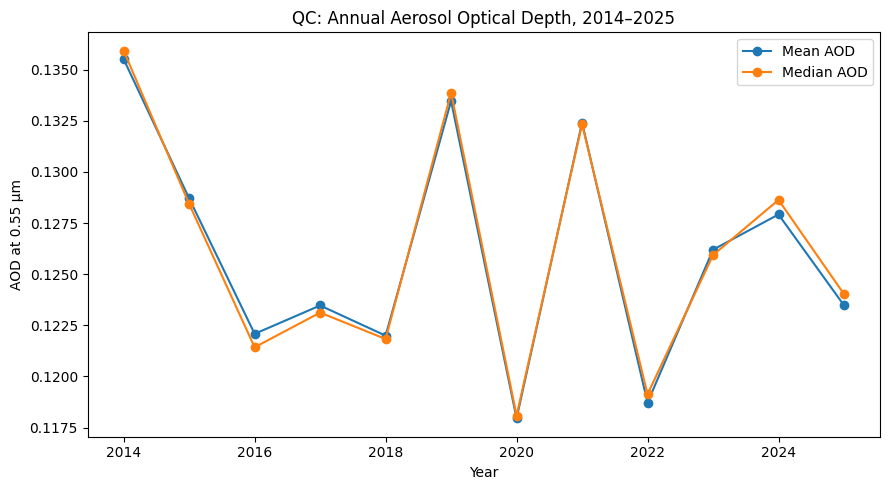

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_air_quality_aod_trend.png


In [22]:
import matplotlib.pyplot as plt

annual_air = (
    air_panel
    .groupby("year")["aod_055"]
    .agg(
        mean="mean",
        median="median"
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_air["year"],
    annual_air["mean"],
    marker="o",
    label="Mean AOD"
)

ax.plot(
    annual_air["year"],
    annual_air["median"],
    marker="o",
    label="Median AOD"
)

ax.set_xlabel("Year")
ax.set_ylabel("AOD at 0.55 μm")
ax.set_title("QC: Annual Aerosol Optical Depth, 2014–2025")
ax.legend()

plt.tight_layout()

out = (
    FIGURES /
    "qc_air_quality_aod_trend.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)